# EDA 08 — RELINTs (Relatórios de Inteligência de Área)

Este notebook explora o **corpus de RELINTs** entregue para a hackathon CompStat Rio.

**O que são RELINTs?** Relatórios de Inteligência de Área são documentos analíticos
produzidos como subsídio para as reuniões CompStat. Cada RELINT consolida, para um
recorte territorial específico (uma estação, um corredor, um conjunto de vias):

- **Análise territorial** — pontos sensíveis, áreas de sombra, fluxos.
- **Fatores urbanos** — iluminação, vegetação, calçadas, mobiliário, comércio irregular, PSR.
- **Dinâmica criminal** — modus operandi, horários, perfis de vítimas, rotas de fuga.
- **Conclusão / plano de ação** — recomendações por órgão responsável.

**Por que importa para a hackathon?** As RELINTs são o **gold standard** — o
*output* que a IA do desafio principal precisa aprender a gerar a partir dos
dados brutos (ocorrências, Disk Denúncia, fatores urbanos). Entender a sua
estrutura, vocabulário e padrões é pré-requisito para qualquer abordagem
generativa.

Corpus: 8 documentos `.docx` em `relints/`.

## 1. Carregamento

Os RELINTs são documentos `.docx` curtos (~6–7 KB cada). O conteúdo real **está
dentro de uma tabela de uma única coluna** — então precisamos extrair tanto
parágrafos soltos quanto células de tabela.

In [1]:
import os
import re
import glob
from collections import Counter
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from docx import Document

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Resolve the relints directory robustly (works whether the notebook is run
# from notebooks/eda/ or from the repo root via the in-process executor).
def _resolve_relints_dir():
    for candidate in ['../../relints', '../relints', 'relints',
                      os.path.expanduser('~/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio/relints')]:
        if os.path.isdir(candidate):
            return candidate
    raise FileNotFoundError('relints/ not found')

RELINTS_DIR = _resolve_relints_dir()
files = sorted(glob.glob(os.path.join(RELINTS_DIR, '*.docx')))
print(f'{len(files)} RELINTs encontrados')
for f in files:
    print(' -', os.path.basename(f))

8 RELINTs encontrados
 - Cópia de RI_010_2026_Rodoviaria_Terminal_Gentileza.docx
 - Cópia de RI_011_2026_Metro_Botafogo_Sao_Clemente.docx
 - Cópia de RI_012_2026_Jardim_de_Alah.docx
 - Cópia de RI_013_2026_Campo_Grande_Estacao_Calcadao.docx
 - Cópia de RI_014_2026_Rio_Sul.docx
 - Cópia de RI_015_2026_Praia_Botafogo_Marques_Abrantes.docx
 - Cópia de RI_016_2026_Estacoes_SFX_Afonso_Pena.docx
 - Cópia de RI_017_2026_Presidente_Vargas_Campo_Santana.docx


In [2]:
def load_relint(path):
    """Extrai todos os parágrafos (incluindo células de tabela) de um .docx."""
    doc = Document(path)
    parts = []
    for p in doc.paragraphs:
        t = p.text.strip()
        if t:
            parts.append(t)
    for tab in doc.tables:
        for row in tab.rows:
            for cell in row.cells:
                t = cell.text.strip()
                if t:
                    parts.append(t)
    return parts


def area_from_filename(fname):
    base = os.path.basename(fname).replace('.docx', '')
    # remove "Cópia de RI_XXX_2026_" prefix
    m = re.match(r'(Cópia de )?RI_(\d+)_\d+_(.+)', base)
    if m:
        slug = m.group(3)
        return slug.replace('_', ' ')
    return base


rows = []
for f in files:
    paras = load_relint(f)
    raw = '\n'.join(paras)
    rows.append({
        'arquivo': os.path.basename(f),
        'area_fm': area_from_filename(f),
        'raw_text': raw,
        'n_paragraphs': len(paras),
        'n_chars': len(raw),
        'n_words': len(raw.split()),
    })

df_rel = pd.DataFrame(rows)
df_rel[['arquivo', 'area_fm', 'n_paragraphs', 'n_chars', 'n_words']]

Out[0]: 
                                                     arquivo  ... n_words
0    Cópia de RI_010_2026_Rodoviaria_Terminal_Gentileza.docx  ...     911
1      Cópia de RI_011_2026_Metro_Botafogo_Sao_Clemente.docx  ...     870
2                   Cópia de RI_012_2026_Jardim_de_Alah.docx  ...     860
3    Cópia de RI_013_2026_Campo_Grande_Estacao_Calcadao.docx  ...     866
4                          Cópia de RI_014_2026_Rio_Sul.docx  ...     857
5  Cópia de RI_015_2026_Praia_Botafogo_Marques_Abrantes.docx  ...     868
6         Cópia de RI_016_2026_Estacoes_SFX_Afonso_Pena.docx  ...     905
7  Cópia de RI_017_2026_Presidente_Vargas_Campo_Santana.docx  ...    1160

[8 rows x 5 columns]


,arquivo,area_fm,n_paragraphs,n_chars,n_words
0,Cópia de RI_010_2026_Rodoviaria_Terminal_Gentileza.docx,Rodoviaria Terminal Gentileza,12,6355,911
1,Cópia de RI_011_2026_Metro_Botafogo_Sao_Clemente.docx,Metro Botafogo Sao Clemente,12,6029,870
2,Cópia de RI_012_2026_Jardim_de_Alah.docx,Jardim de Alah,12,5815,860
3,Cópia de RI_013_2026_Campo_Grande_Estacao_Calcadao.docx,Campo Grande Estacao Calcadao,12,6152,866
4,Cópia de RI_014_2026_Rio_Sul.docx,Rio Sul,12,5951,857
5,Cópia de RI_015_2026_Praia_Botafogo_Marques_Abrantes.docx,Praia Botafogo Marques Abrantes,12,5842,868
6,Cópia de RI_016_2026_Estacoes_SFX_Afonso_Pena.docx,Estacoes SFX Afonso Pena,12,6121,905
7,Cópia de RI_017_2026_Presidente_Vargas_Campo_Santana.docx,Presidente Vargas Campo Santana,12,7583,1160


## 2. Tamanho dos documentos

Sanity check: as 8 RELINTs têm tamanho parecido (~1000 palavras), o que sugere
um **template estável**. Variações apontam principalmente para áreas mais
complexas (mais subáreas) ou mais densas em narrativa.

Média: 912 palavras  |  desvio: 102


<ipython-input-1-3f07aa77061a>:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


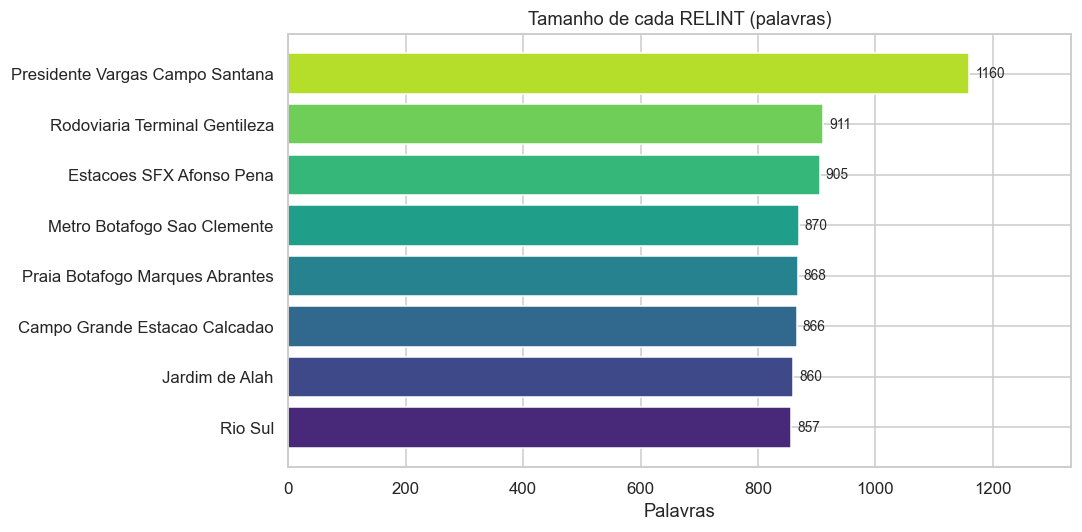

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
order = df_rel.sort_values('n_words', ascending=True)
ax.barh(order['area_fm'], order['n_words'], color=sns.color_palette('viridis', len(order)))
for i, (_, r) in enumerate(order.iterrows()):
    ax.text(r['n_words'] + 10, i, str(r['n_words']), va='center', fontsize=9)
ax.set_xlabel('Palavras')
ax.set_title('Tamanho de cada RELINT (palavras)')
ax.set_xlim(0, order['n_words'].max() * 1.15)
plt.tight_layout()
plt.show()
print(f'Média: {df_rel.n_words.mean():.0f} palavras  |  desvio: {df_rel.n_words.std():.0f}')

## 3. Detecção de seções

Cada RELINT segue um padrão de macro-estrutura:

1. Cabeçalho institucional (`RELATÓRIO DE INTELIGÊNCIA DE ÁREA — COMPSTAT`).
2. Nome da área analisada.
3. Parágrafo introdutório.
4. **Subáreas** — cada uma com um cabeçalho curto em CAIXA ALTA + parágrafo descritivo.
5. `CONCLUSÃO`.

Heurística para detectar cabeçalhos: parágrafos curtos (< 80 chars), majoritariamente
maiúsculos. Para seções nomeadas, procuramos palavras-chave conhecidas.

In [4]:
SECTION_KEYWORDS = [
    'RELATÓRIO DE INTELIGÊNCIA',
    'COMPSTAT',
    'CONCLUSÃO',
    'DINÂMICA CRIMINAL',
    'PLANO DE AÇÃO',
    'FATORES URBANOS',
    'RECOMENDAÇÕES',
    'ANÁLISE TERRITORIAL',
    'AÇÕES',
]


def is_header_like(p):
    if len(p) > 90:
        return False
    letters = [c for c in p if c.isalpha()]
    if not letters:
        return False
    upper_ratio = sum(1 for c in letters if c.isupper()) / len(letters)
    return upper_ratio >= 0.85


# count header-like paragraphs and section-keyword hits per doc
sec_rows = []
for _, r in df_rel.iterrows():
    paras = r['raw_text'].split('\n')
    headers = [p for p in paras if is_header_like(p)]
    row = {'area_fm': r['area_fm'], 'n_headers_caps': len(headers)}
    text_up = r['raw_text'].upper()
    for kw in SECTION_KEYWORDS:
        row[kw] = int(kw in text_up)
    sec_rows.append(row)

df_sections = pd.DataFrame(sec_rows).set_index('area_fm')
df_sections

Out[0]: 
                                 n_headers_caps  ...  AÇÕES
area_fm                                          ...       
Rodoviaria Terminal Gentileza                 7  ...      1
Metro Botafogo Sao Clemente                   7  ...      1
Jardim de Alah                                7  ...      1
Campo Grande Estacao Calcadao                 7  ...      1
Rio Sul                                       7  ...      1
Praia Botafogo Marques Abrantes               7  ...      1
Estacoes SFX Afonso Pena                      7  ...      1
Presidente Vargas Campo Santana               7  ...      1

[8 rows x 10 columns]


,n_headers_caps,RELATÓRIO DE INTELIGÊNCIA,COMPSTAT,CONCLUSÃO,DINÂMICA CRIMINAL,PLANO DE AÇÃO,FATORES URBANOS,RECOMENDAÇÕES,ANÁLISE TERRITORIAL,AÇÕES
area_fm,,,,,,,,,,
Rodoviaria Terminal Gentileza,7,1,1,1,1,0,1,0,1,1
Metro Botafogo Sao Clemente,7,1,1,1,1,0,1,0,1,1
Jardim de Alah,7,1,1,1,1,0,1,0,1,1
Campo Grande Estacao Calcadao,7,1,1,1,1,0,1,0,1,1
Rio Sul,7,1,1,1,1,0,1,0,0,1
Praia Botafogo Marques Abrantes,7,1,1,1,1,0,1,0,1,1
Estacoes SFX Afonso Pena,7,1,1,1,1,0,1,0,1,1
Presidente Vargas Campo Santana,7,1,1,1,1,0,1,0,1,1


<ipython-input-1-052ff7b2e676>:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


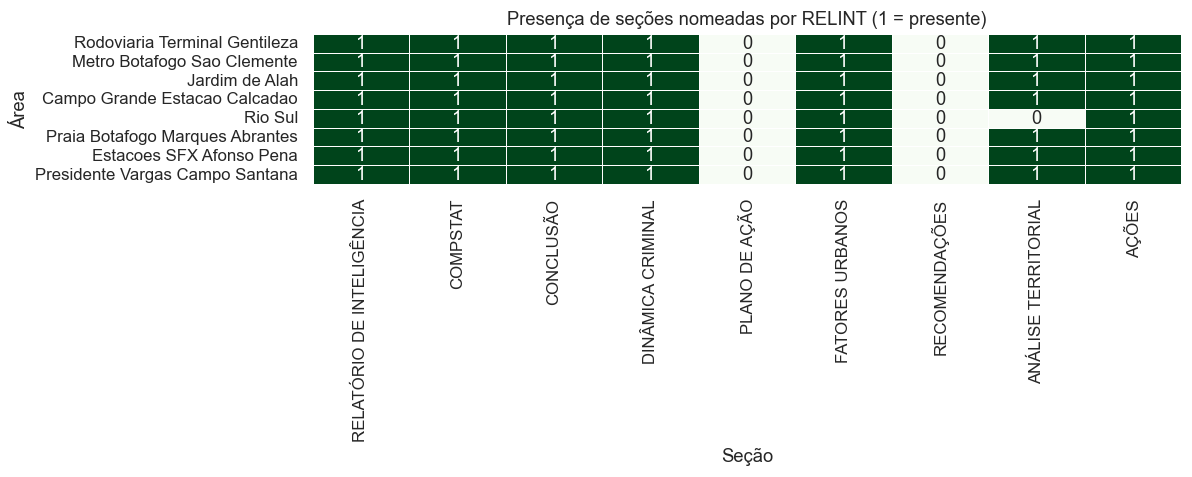

In [5]:
# Heatmap de presença de seções nomeadas
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(df_sections[SECTION_KEYWORDS].astype(int),
            cmap='Greens', annot=True, fmt='d', cbar=False,
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Presença de seções nomeadas por RELINT (1 = presente)')
ax.set_xlabel('Seção')
ax.set_ylabel('Área')
plt.tight_layout()
plt.show()

In [6]:
# Exemplo: liste os cabeçalhos detectados em uma das RELINTs
ex = df_rel.iloc[0]
print(f"=== Cabeçalhos detectados em: {ex['area_fm']} ===")
for p in ex['raw_text'].split('\n'):
    if is_header_like(p):
        print(' •', p)

=== Cabeçalhos detectados em: Rodoviaria Terminal Gentileza ===
 • RELATÓRIO DE INTELIGÊNCIA DE ÁREA – COMPSTAT – DADOS PÚBLICOS
 • RELATÓRIO DE INTELIGÊNCIA DE ÁREA
 • RODOVIÁRIA – TERMINAL GENTILEZA – ESTAÇÃO LEOPOLDINA
 • RODOVIÁRIA NOVO RIO
 • TERMINAL INTERMODAL GENTILEZA
 • ESTAÇÃO LEOPOLDINA
 • CONCLUSÃO


## 4. Vocabulário comum

Top 30 tokens mais frequentes do corpus, após remoção de uma lista pequena de
*stopwords* PT-BR e filtros básicos (apenas letras, length > 2). Esperamos ver
o vocabulário-núcleo do domínio CompStat: *furto*, *roubo*, *pedestres*,
*celulares*, *fluxo*, *iluminação*…

Out[0]: 
            token  freq
0         acessos    57
1         urbanos    56
2      circulação    53
3    motocicletas    53
4      bicicletas    51
5           fluxo    50
6        horários    49
7       pedestres    46
8    visibilidade    45
9      iluminação    40
10     transporte    39
11           pico    39
12        público    38
13        delitos    37
14      dispersão    37
15      múltiplas    35
16       retenção    34
17          rotas    34
18       dinâmica    33
19       criminal    33
20     travessias    33
21        prática    32
22     obstáculos    32
23          baixa    31
24        intensa    31
25         furtos    30
26   aproveitando    30
27  especialmente    29
28     vigilância    29
29      criminosa    29


<ipython-input-1-1bf907360ec4>:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


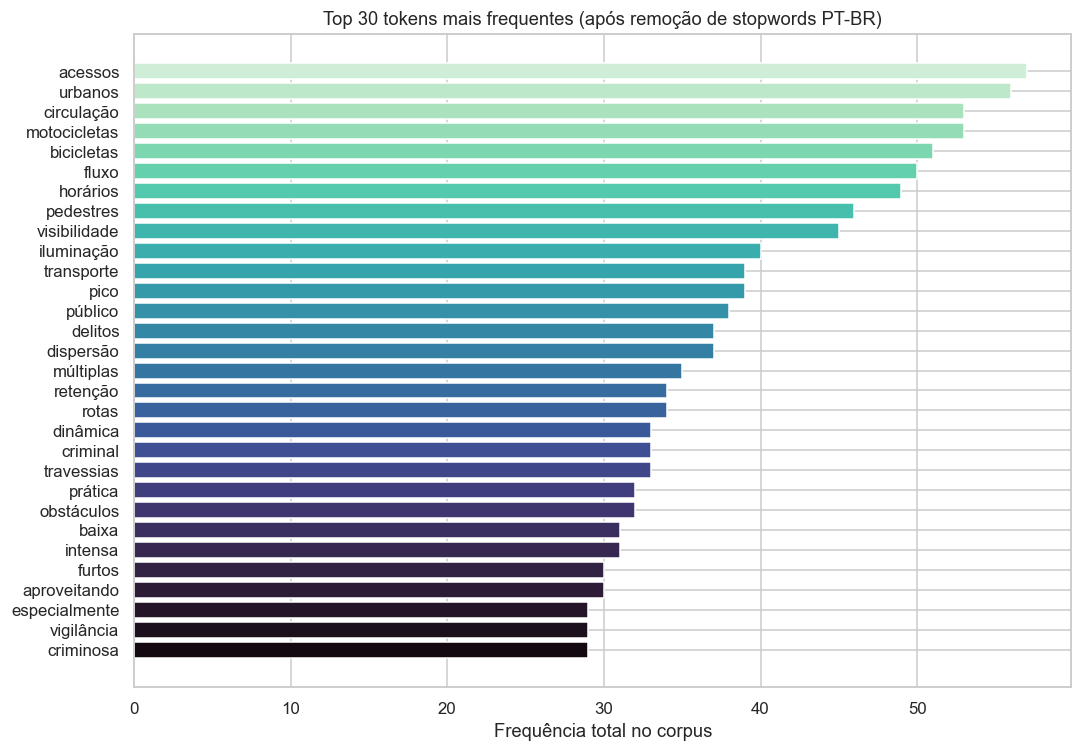

,token,freq
0,acessos,57
1,urbanos,56
2,circulação,53
3,motocicletas,53
4,bicicletas,51
5,fluxo,50
6,horários,49
7,pedestres,46
8,visibilidade,45
9,iluminação,40


In [7]:
STOPWORDS_PT = set('''
a o e é da do de das dos um uma uns umas no na nos nas em por para com sem sob sobre
que qual quais quando onde como porque pois mas ou se ja já também tambem ate até
ser sao são é foi era foram tem têm ter sua seu suas seus suas este esta estes estas
esse essa esses essas isto isso aquilo aquele aquela aqueles aquelas pelo pela pelos pelas
ao aos à às mais menos muito muita muitos muitas pouco pouca poucos poucas
entre apos após mesmo mesma mesmos mesmas outro outra outros outras
não nao sim já jamais nunca sempre talvez apenas
seu sua seus suas dele dela deles delas
nesse nessa nesses nessas neste nesta nestes nestas
em de para com por sem sob sobre entre durante perante mediante conforme segundo
ainda também tambem inclusive
nº n número numero
'''.split())

# add a few generic but unhelpful terms specific to the corpus
STOPWORDS_PT.update({'área','areas','áreas','rua','ruas','avenida','vias','via','foram','pode','podem','presente','presenta','apresentam','apresenta','realizada','realizado','observa','observados','observada','observado','também','ainda','grande','grandes','principal','principais','setor','setores','ponto','pontos','local','locais','fator','fatores','elemento','elementos','região','regiões','onde','quando','enquanto'})

def tokenize(text):
    text = text.lower()
    # keep accented letters
    toks = re.findall(r"[a-záàâãéèêíìîóòôõúùûç]+", text)
    return [t for t in toks if len(t) > 2 and t not in STOPWORDS_PT]


all_tokens = []
for _, r in df_rel.iterrows():
    all_tokens.extend(tokenize(r['raw_text']))

freq = Counter(all_tokens)
top30 = freq.most_common(30)
df_top = pd.DataFrame(top30, columns=['token', 'freq'])

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(df_top['token'][::-1], df_top['freq'][::-1], color=sns.color_palette('mako', 30))
ax.set_xlabel('Frequência total no corpus')
ax.set_title('Top 30 tokens mais frequentes (após remoção de stopwords PT-BR)')
plt.tight_layout()
plt.show()
df_top

## 5. *Fingerprint* TF-IDF por RELINT

Para cada documento, calculamos os 15 termos mais **distintivos** — aqueles que
aparecem muito naquele RELINT mas pouco no resto do corpus. Como `scikit-learn`
não está disponível no ambiente, implementamos TF-IDF à mão:

- `tf(t, d)` = frequência relativa do termo `t` no documento `d`.
- `idf(t)` = `log(N / df(t))`, onde `df(t)` é o número de docs em que `t` aparece.
- `tfidf = tf * idf`.

In [8]:
docs_tokens = [tokenize(t) for t in df_rel['raw_text']]
N = len(docs_tokens)

# document frequency
df_t = Counter()
for toks in docs_tokens:
    for t in set(toks):
        df_t[t] += 1

# term frequencies per doc (relative)
tf_per_doc = []
for toks in docs_tokens:
    c = Counter(toks)
    total = sum(c.values()) or 1
    tf_per_doc.append({t: n / total for t, n in c.items()})

# tf-idf
tfidf_per_doc = []
for tf in tf_per_doc:
    row = {}
    for t, v in tf.items():
        idf = math.log(N / df_t[t]) if df_t[t] else 0.0
        row[t] = v * idf
    tfidf_per_doc.append(row)


def top_n(d, n=15):
    return sorted(d.items(), key=lambda kv: kv[1], reverse=True)[:n]


fingerprint = {df_rel.iloc[i]['area_fm']: top_n(tfidf_per_doc[i], 15) for i in range(N)}
for area, terms in fingerprint.items():
    print(f'\n--- {area} ---')
    print('  ', ', '.join(f'{t} ({s:.3f})' for t, s in terms))


--- Rodoviaria Terminal Gentileza ---
   terminal (0.028), rodoviária (0.024), leopoldina (0.024), gentileza (0.020), viadutos (0.020), desembarque (0.016), linhas (0.013), novo (0.012), embarque (0.012), infraestrutura (0.012), degradada (0.012), plataformas (0.012), passarelas (0.011), estação (0.008), municipais (0.008)

--- Metro Botafogo Sao Clemente ---
   clemente (0.025), voluntários (0.021), pátria (0.021), metrô (0.016), bares (0.014), comerciais (0.012), botafogo (0.010), grades (0.008), arborização (0.008), estabelecimentos (0.008), noturna (0.006), estacionados (0.006), escadas (0.006), bancas (0.006), informal (0.006)

--- Jardim de Alah ---
   passagens (0.046), internas (0.030), obras (0.025), orla (0.022), nichos (0.017), jardim (0.013), alah (0.013), revitalização (0.013), tapumes (0.013), formados (0.013), leblon (0.013), ataulfo (0.013), paiva (0.013), internos (0.008), praia (0.008)

--- Campo Grande Estacao Calcadao ---
   calçadão (0.042), secundárias (0.025), c

In [9]:
# tabela compacta: top-15 termos por RELINT (apenas os tokens)
fp_table = {area: [t for t, _ in terms] for area, terms in fingerprint.items()}
df_fp = pd.DataFrame({area: pd.Series(toks) for area, toks in fp_table.items()})
df_fp.index = [f'#{i+1}' for i in range(len(df_fp))]
df_fp.T

Out[0]: 
                                        #1  ...          #15
Rodoviaria Terminal Gentileza     terminal  ...   municipais
Metro Botafogo Sao Clemente       clemente  ...     informal
Jardim de Alah                   passagens  ...        praia
Campo Grande Estacao Calcadao     calçadão  ...  ferroviária
Rio Sul                              lauro  ...       rampas
Praia Botafogo Marques Abrantes   flamengo  ...    viabiliza
Estacoes SFX Afonso Pena            afonso  ...   estudantil
Presidente Vargas Campo Santana    central  ...         país

[8 rows x 15 columns]


,#1,#2,#3,#4,#5,#6,#7,#8,#9,#10,#11,#12,#13,#14,#15
Rodoviaria Terminal Gentileza,terminal,rodoviária,leopoldina,gentileza,viadutos,desembarque,linhas,novo,embarque,infraestrutura,degradada,plataformas,passarelas,estação,municipais
Metro Botafogo Sao Clemente,clemente,voluntários,pátria,metrô,bares,comerciais,botafogo,grades,arborização,estabelecimentos,noturna,estacionados,escadas,bancas,informal
Jardim de Alah,passagens,internas,obras,orla,nichos,jardim,alah,revitalização,tapumes,formados,leblon,ataulfo,paiva,internos,praia
Campo Grande Estacao Calcadao,calçadão,secundárias,comunidades,estação,ambulantes,influência,organizações,criminosas,ferroviários,campo,visual,imediato,orcrim,facilitam,ferroviária
Rio Sul,lauro,ller,escadarias,shopping,saúde,profissionais,carlos,peixoto,hospitalar,entroncamento,arborização,tarde,hospitais,universidades,rampas
Praia Botafogo Marques Abrantes,flamengo,marquês,abrantes,orla,botafogo,parque,iluminados,praia,extensão,estabelecimentos,noturnos,barreiras,ciclofaixa,bares,viabiliza
Estacoes SFX Afonso Pena,afonso,pena,praça,xavier,francisco,secundárias,tijuca,estações,escolar,residenciais,estação,entrada,bancas,informal,estudantil
Presidente Vargas Campo Santana,central,brasil,presidente,vargas,santana,cinelândia,floriano,praça,campo,uruguaiana,centro,camelódromo,registros,irregular,país


## 6. Órgãos / agências mencionadas

A literatura COMPSTAT prevê planos de ação por órgão responsável (COMLURB,
RIOLUZ, SECONSERVA, CET-Rio, SMAS, SEOP, GM-Rio, SMTR…). Conferimos quantos
desses órgãos são citados nominalmente em cada RELINT. *Observação esperada:*
estas RELINTs específicas privilegiam diagnóstico territorial, então a
incidência de nomes de órgãos é baixa — o que é, em si, um achado.

In [10]:
AGENCY_PATTERNS = {
    'COMLURB': r'\bCOMLURB\b',
    'RIOLUZ': r'\bRIO\s?LUZ\b',
    'SECONSERVA': r'\bSECONSERVA\b',
    'CET-RIO': r'\bCET[-\s]?RIO\b',
    'SMAS': r'\bSMAS\b',
    'SEOP': r'\bSEOP\b',
    'GM-RIO': r'\b(GM[-\s]?RIO|GUARDA\s+MUNICIPAL)\b',
    'SMTR': r'\bSMTR\b',
    # extra agencies that DO appear, for context:
    'PMERJ': r'\bPMERJ\b',
    'PCERJ': r'\bPCERJ\b',
    'MetrôRio': r'\bMETR[ÔO]RIO\b',
    'SuperVia': r'\bSUPERVIA\b',
}

agency_rows = []
for _, r in df_rel.iterrows():
    text_up = r['raw_text'].upper()
    row = {'area_fm': r['area_fm']}
    for name, patt in AGENCY_PATTERNS.items():
        row[name] = len(re.findall(patt, text_up))
    agency_rows.append(row)

df_agencies = pd.DataFrame(agency_rows).set_index('area_fm')
df_agencies

Out[0]: 
                                 COMLURB  RIOLUZ  ...  MetrôRio  SuperVia
area_fm                                           ...                    
Rodoviaria Terminal Gentileza          0       0  ...         0         0
Metro Botafogo Sao Clemente            0       0  ...         1         0
Jardim de Alah                         0       0  ...         0         0
Campo Grande Estacao Calcadao          0       0  ...         0         1
Rio Sul                                0       0  ...         0         0
Praia Botafogo Marques Abrantes        0       0  ...         0         0
Estacoes SFX Afonso Pena               0       0  ...         1         0
Presidente Vargas Campo Santana        0       0  ...         1         1

[8 rows x 12 columns]


,COMLURB,RIOLUZ,SECONSERVA,CET-RIO,SMAS,SEOP,GM-RIO,SMTR,PMERJ,PCERJ,MetrôRio,SuperVia
area_fm,,,,,,,,,,,,
Rodoviaria Terminal Gentileza,0,0,0,0,0,0,0,0,1,0,0,0
Metro Botafogo Sao Clemente,0,0,0,0,0,0,0,0,1,0,1,0
Jardim de Alah,0,0,0,0,0,0,0,0,1,0,0,0
Campo Grande Estacao Calcadao,0,0,0,0,0,0,0,0,1,1,0,1
Rio Sul,0,0,0,0,0,0,0,0,1,0,0,0
Praia Botafogo Marques Abrantes,0,0,0,0,0,0,0,0,1,0,0,0
Estacoes SFX Afonso Pena,0,0,0,0,0,0,0,0,1,0,1,0
Presidente Vargas Campo Santana,0,0,0,0,0,1,0,0,1,1,1,1


Total de menções por órgão (corpus):
PMERJ         8
MetrôRio      3
PCERJ         2
SuperVia      2
SEOP          1
COMLURB       0
RIOLUZ        0
SECONSERVA    0
CET-RIO       0
SMAS          0
GM-RIO        0
SMTR          0
dtype: int64


<ipython-input-1-7c406cb10aea>:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


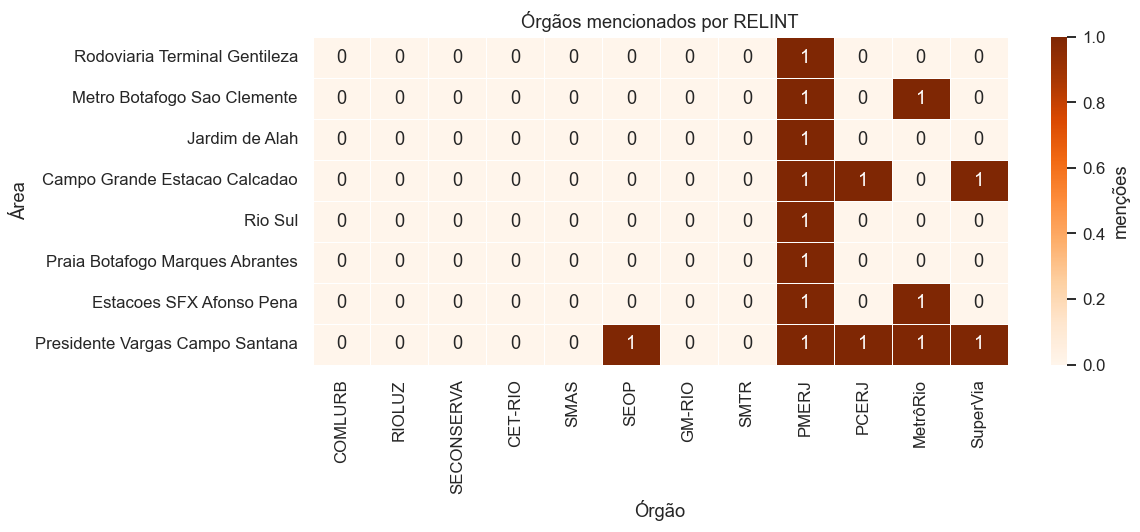

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(df_agencies, cmap='Oranges', annot=True, fmt='d',
            linewidths=0.4, linecolor='white', cbar_kws={'label': 'menções'}, ax=ax)
ax.set_title('Órgãos mencionados por RELINT')
ax.set_xlabel('Órgão')
ax.set_ylabel('Área')
plt.tight_layout()
plt.show()

print('Total de menções por órgão (corpus):')
print(df_agencies.sum().sort_values(ascending=False))

## 7. Fatores urbanos mencionados

Contagem das menções a fatores urbanos canônicos por RELINT. Este vocabulário
forma o **núcleo do plano de ação** que uma IA geradora precisa dominar:
cada fator mapeia para um órgão responsável (iluminação → RIOLUZ; vegetação →
COMLURB; calçada → SECONSERVA; comércio irregular → SEOP; PSR → SMAS;
mobiliário urbano → SECONSERVA; estacionamento/motocicleta → CET-Rio;
ponto de ônibus → SMTR).

In [12]:
FACTOR_PATTERNS = {
    'iluminação': r'ilumina[çc][ãa]o',
    'vegetação': r'vegeta[çc][ãa]o|arboriza[çc][ãa]o',
    'calçada': r'cal[çc]ada',
    'comércio irregular': r'com[ée]rcio\s+irregular|ambulant',
    'PSR': r'(?:pessoas?|popula[çc][ãa]o)\s+em\s+situa[çc][ãa]o\s+de\s+rua|\bPSR\b',
    'drogas': r'drogas?|entorpec',
    'mobiliário': r'mobili[áa]rio',
    'estacionamento': r'estacion',
    'motocicleta': r'motociclet|moto\s|motos\b',
    'vandalismo': r'vandalismo|deprediç|degrada',
    'ponto de ônibus': r'ponto\s+de\s+[ôo]nibus|pontos\s+de\s+[ôo]nibus',
    'câmeras': r'c[âa]mer',
    'área de sombra': r'[áa]rea[s]?\s+de\s+sombra|pontos?\s+cego',
}

fac_rows = []
for _, r in df_rel.iterrows():
    text_low = r['raw_text'].lower()
    row = {'area_fm': r['area_fm']}
    for name, patt in FACTOR_PATTERNS.items():
        row[name] = len(re.findall(patt, text_low))
    fac_rows.append(row)

df_factors = pd.DataFrame(fac_rows).set_index('area_fm')
df_factors

Out[0]: 
                                 iluminação  vegetação  ...  câmeras  área de sombra
area_fm                                                 ...                         
Rodoviaria Terminal Gentileza             4          0  ...        1               5
Metro Botafogo Sao Clemente               6          4  ...        0               0
Jardim de Alah                            5          4  ...        0               3
Campo Grande Estacao Calcadao             4          0  ...        0               2
Rio Sul                                   3          5  ...        2               7
Praia Botafogo Marques Abrantes           6          2  ...        0               1
Estacoes SFX Afonso Pena                  9          4  ...        0               0
Presidente Vargas Campo Santana           3          3  ...        0               1

[8 rows x 13 columns]


,iluminação,vegetação,calçada,comércio irregular,PSR,drogas,mobiliário,estacionamento,motocicleta,vandalismo,ponto de ônibus,câmeras,área de sombra
area_fm,,,,,,,,,,,,,
Rodoviaria Terminal Gentileza,4,0,1,3,1,0,0,0,6,3,0,1,5
Metro Botafogo Sao Clemente,6,4,7,0,0,0,0,3,9,0,1,0,0
Jardim de Alah,5,4,0,0,0,0,0,0,6,0,0,0,3
Campo Grande Estacao Calcadao,4,0,1,8,0,0,0,0,8,0,0,0,2
Rio Sul,3,5,3,0,0,0,0,3,6,0,2,2,7
Praia Botafogo Marques Abrantes,6,2,2,0,1,0,0,0,7,0,0,0,1
Estacoes SFX Afonso Pena,9,4,3,0,1,1,0,1,7,0,3,0,0
Presidente Vargas Campo Santana,3,3,2,4,1,1,0,0,7,0,3,0,1


Total no corpus, ordenado:
motocicleta           56
iluminação            40
vegetação             22
calçada               19
área de sombra        19
comércio irregular    15
ponto de ônibus        9
estacionamento         7
PSR                    4
vandalismo             3
câmeras                3
drogas                 2
mobiliário             0
dtype: int64


<ipython-input-1-c909ba1499e7>:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


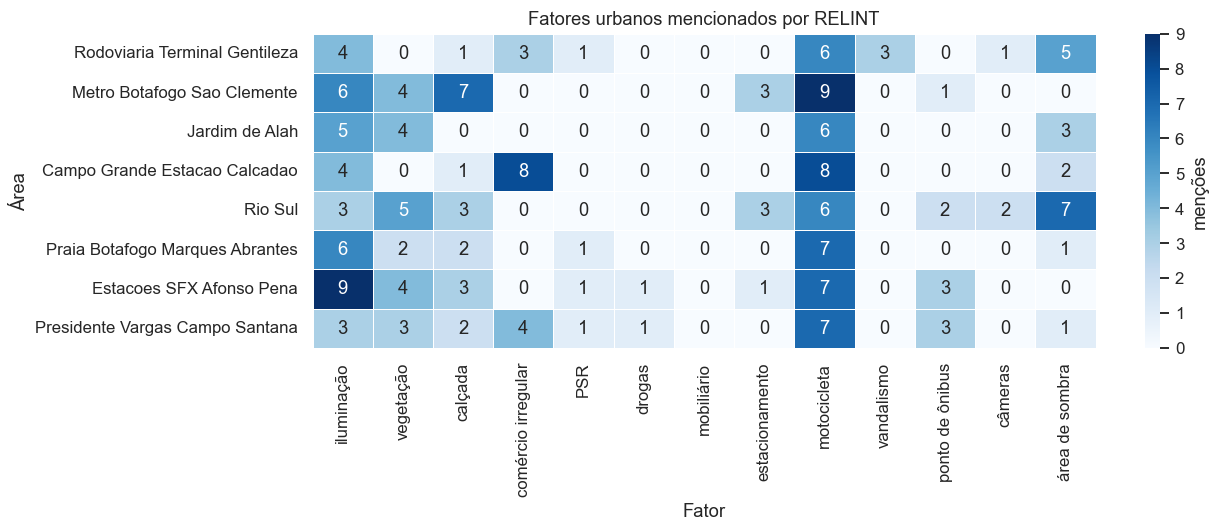

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df_factors, cmap='Blues', annot=True, fmt='d',
            linewidths=0.4, linecolor='white', cbar_kws={'label': 'menções'}, ax=ax)
ax.set_title('Fatores urbanos mencionados por RELINT')
ax.set_xlabel('Fator')
ax.set_ylabel('Área')
plt.tight_layout()
plt.show()

print('Total no corpus, ordenado:')
print(df_factors.sum().sort_values(ascending=False))

## 8. Parágrafo-exemplo por RELINT

Para que o leitor capte o **estilo** dos RELINTs (formal, denso em substantivos,
geo-referenciado, com horários e número de fluxos), imprimimos o primeiro
parágrafo com mais de 200 caracteres de cada documento.

In [14]:
for _, r in df_rel.iterrows():
    paras = [p for p in r['raw_text'].split('\n') if len(p) > 200]
    if not paras:
        continue
    sample = paras[0]
    snippet = sample[:600] + ('…' if len(sample) > 600 else '')
    print(f'\n=== {r["area_fm"]} ===')
    print(snippet)


=== Rodoviaria Terminal Gentileza ===
A presente análise territorial visa identificar fatores urbanos, dinâmica criminal e vulnerabilidades relacionadas à sensação de segurança da população, considerando áreas de grande circulação de pedestres e integração com o transporte público. Foram observados fatores associados à incidência de furtos e roubos contra transeuntes, especialmente subtração de aparelhos celulares, além de elementos urbanos que favorecem delitos oportunistas.

=== Metro Botafogo Sao Clemente ===
A presente análise territorial visa identificar fatores urbanos, dinâmica criminal e vulnerabilidades relacionadas à sensação de segurança da população, considerando áreas de grande circulação de pedestres e integração com o transporte público. Foram observados fatores associados à incidência de furtos e roubos contra transeuntes, especialmente subtração de aparelhos celulares, além de elementos urbanos que favorecem delitos oportunistas.

=== Jardim de Alah ===
A presente aná

## 9. Conclusões — o que uma IA geradora precisa aprender

A partir desta EDA, o **template implícito** que um modelo gerador deve reproduzir é:

1. **Macro-estrutura fixa** (5 blocos):
   - Cabeçalho institucional `RELATÓRIO DE INTELIGÊNCIA DE ÁREA – COMPSTAT`.
   - Nome da área (composto, ex.: *Rodoviária – Terminal Gentileza – Estação Leopoldina*).
   - Parágrafo de enquadramento (introdução padronizada).
   - 2–4 **subáreas**, cada uma com cabeçalho em CAIXA ALTA + parágrafo descritivo (~1300 chars).
   - Seção `CONCLUSÃO` consolidando os achados.

2. **Vocabulário-núcleo** do corpus (top tokens): *furtos*, *roubos*, *celulares*,
   *pedestres*, *fluxo*, *iluminação*, *calçada*, *PSR*, *rota(s) de fuga*.

3. **Mecânica narrativa** por subárea: contexto territorial → fluxos e horários →
   fatores físicos (iluminação, vegetação, calçada, comércio irregular) →
   modus operandi observado → rota de fuga/dispersão.

4. **Granularidade geográfica**: nomes próprios de logradouros, alturas (`nº 580`),
   integrações de transporte (BRT, SuperVia, MetrôRio, VLT), órgãos institucionais
   nomeados (PMERJ, PCERJ, INEPAC).

5. **Lacuna observada**: estas RELINTs **descritivas** quase não citam órgãos
   municipais executores (COMLURB/RIOLUZ/SECONSERVA/etc.). Um modelo gerador
   completo precisará produzir, a partir dos *fatores urbanos identificados*,
   o **plano de ação por órgão responsável** — que aparenta ser um passo
   adicional não coberto integralmente neste subconjunto do corpus.

6. **Distintividade por área** (TF-IDF) capta marcadores únicos: *Rodoviária*
   destaca-se por `viaduto`, `terminal`, `passageiros`; *Rio Sul* por
   `lauro müller`, `shopping`, `universidades`; *Pres. Vargas* por
   `camelódromo`, `uruguaiana`, `receptação`.

Estes são os contornos que a fase generativa do desafio precisa respeitar.